<a href="https://colab.research.google.com/github/SiddharthVESIT/SEM6/blob/lab2/mldl_lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

# Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


Saving microsoft_stock_prices_2016_2026_refined.csv to microsoft_stock_prices_2016_2026_refined (1).csv


In [ ]:
df = pd.read_csv("microsoft_stock_prices_2016_2026_refined.csv")

print("Shape:", df.shape)
print(df.head())


Shape: (2513, 6)
         Date      Close       High        Low       Open    Volume
0  2016-02-03  45.671837  46.748837  44.883786  46.626252  57559800
1  2016-02-04  45.531754  46.240999  44.980118  45.619313  46987100
2  2016-02-05  43.920628  45.531751  43.395263  45.479213  62009000
3  2016-02-08  43.263927  43.404025  42.195681  43.386512  59290500
4  2016-02-09  43.150074  43.990662  42.615951  42.922417  46740500


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

df.drop(columns=["Date"], inplace=True)


target = "Close"

X = df.drop(columns=target)
y = df[target]

print("Features:", X.columns.tolist())


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
lr_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("=== Multiple Linear Regression ===")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


=== Multiple Linear Regression ===
R2 Score: 0.99991533042035
MAE: 0.8614416246736942
RMSE: 1.2782863184678366


In [ ]:
lasso_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000))
])

lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

print("\n=== Lasso Regression ===")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))



=== Lasso Regression ===
R2 Score: 0.9997567941224625
MAE: 1.4246375105148943
RMSE: 2.1664639760436026


In [ ]:
ridge_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

print("\n=== Ridge Regression ===")
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))



=== Ridge Regression ===
R2 Score: 0.9997924339350768
MAE: 1.3563212500280017
RMSE: 2.0014401827041897


In [ ]:
feature_names = X.columns

lr_coef = lr_model.named_steps["model"].coef_
lasso_coef = lasso_model.named_steps["model"].coef_
ridge_coef = ridge_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Linear Regression": lr_coef,
    "Lasso": lasso_coef,
    "Ridge": ridge_coef
})

print("Coefficient Comparison:")
print(coef_df)

Coefficient Comparison:
  Feature  Linear Regression       Lasso      Ridge
0    High         115.328019  137.687246  59.199559
1     Low         112.642400    4.151034  59.168709
2    Open         -86.982544   -0.553927  21.798590
3  Volume          -0.035780   -0.807006  -0.151902
4    Year          -0.046897   -0.489971   0.756062
5   Month          -0.042182   -0.054332   0.009360
6     Day           0.039709    0.016711  -0.032865


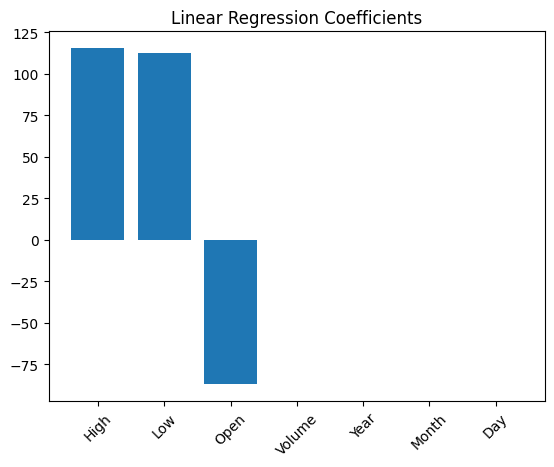

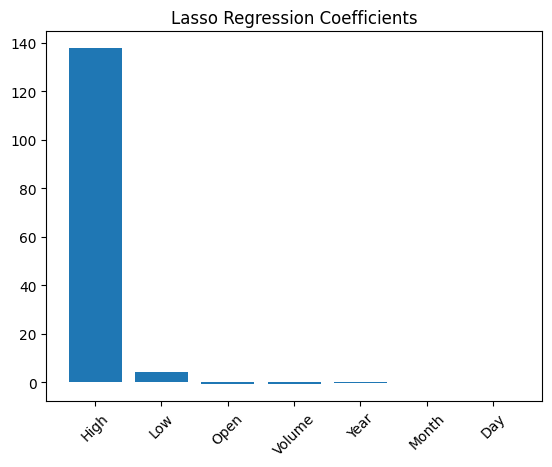

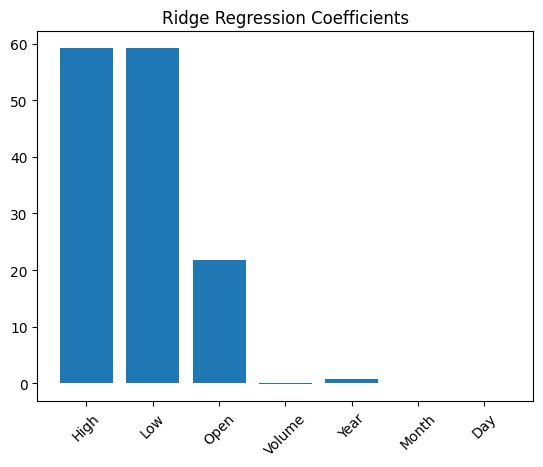

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.bar(feature_names, lr_coef)
plt.title("Linear Regression Coefficients")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.bar(feature_names, lasso_coef)
plt.title("Lasso Regression Coefficients")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.bar(feature_names, ridge_coef)
plt.title("Ridge Regression Coefficients")
plt.xticks(rotation=45)
plt.show()

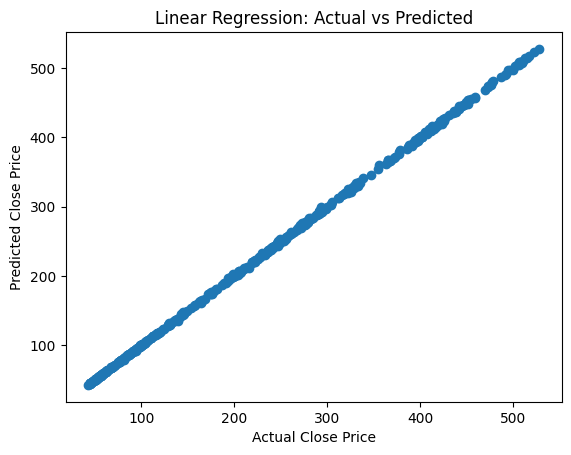

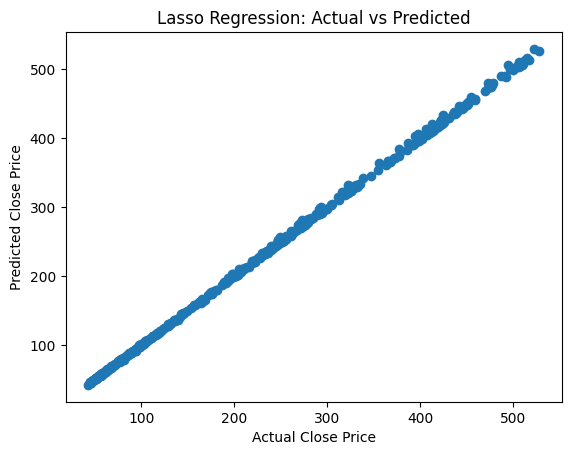

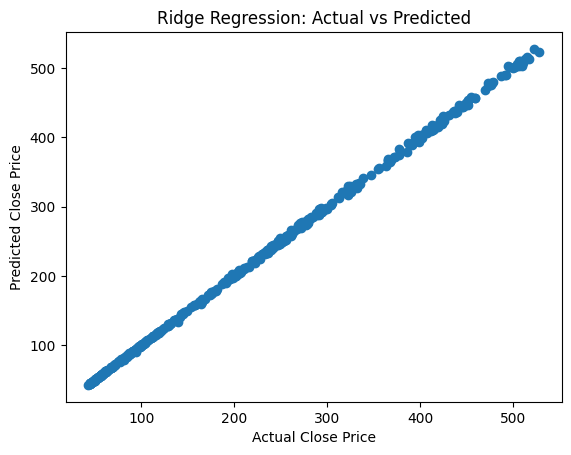

In [ ]:
# Plot 2: Linear Regression Predictions
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

# Plot 3: Lasso Predictions
plt.figure()
plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Lasso Regression: Actual vs Predicted")
plt.show()

# Plot 4: Ridge Predictions
plt.figure()
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()